In [5]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_monthly_summary.csv
/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_yearly_performance.csv
/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_historical_365days.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")


In [7]:
file_path = "/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_historical_365days.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully.
Shape: (33364, 15)


,coin_id,coin_name,symbol,market_cap_rank,timestamp,date,price,market_cap,volume,daily_return,price_ma7,price_ma30,volatility_7d,cumulative_return,month
0,aave,Aave,AAVE,46,2024-12-04 00:00:00,2024-12-04,241.886714,3.633154e+09,1.181708e+09,NaN,241.886714,241.886714,NaN,NaN,2024-12
1,aave,Aave,AAVE,46,2024-12-05 00:00:00,2024-12-05,255.966610,3.841768e+09,1.191179e+09,5.820864,248.926662,248.926662,NaN,5.820864,2024-12
2,aave,Aave,AAVE,46,2024-12-06 00:00:00,2024-12-06,248.589404,3.725870e+09,8.706666e+08,-2.882097,248.814243,248.814243,6.153922,2.771004,2024-12
3,aave,Aave,AAVE,46,2024-12-07 00:00:00,2024-12-07,281.755167,4.226339e+09,1.120551e+09,13.341583,257.049474,257.049474,8.119016,16.482283,2024-12
4,aave,Aave,AAVE,46,2024-12-08 00:00:00,2024-12-08,282.398618,4.241226e+09,6.553344e+08,0.228372,262.119303,262.119303,7.120498,16.748297,2024-12


Weekly Seasonality Table:


,Day,Average_Median_Price
0,Monday,3.844794
1,Tuesday,3.811881
2,Wednesday,3.882432
3,Thursday,3.936910
4,Friday,3.888271
5,Saturday,3.921383
6,Sunday,3.915085


Monthly Seasonality Table:


,Month,Average_Median_Price
0,January,6.574839
1,February,4.782690
2,March,3.842758
3,April,3.587026
4,May,4.052936
5,June,3.086046
6,July,3.150173
7,August,3.239542
8,September,2.655790
9,October,2.212444


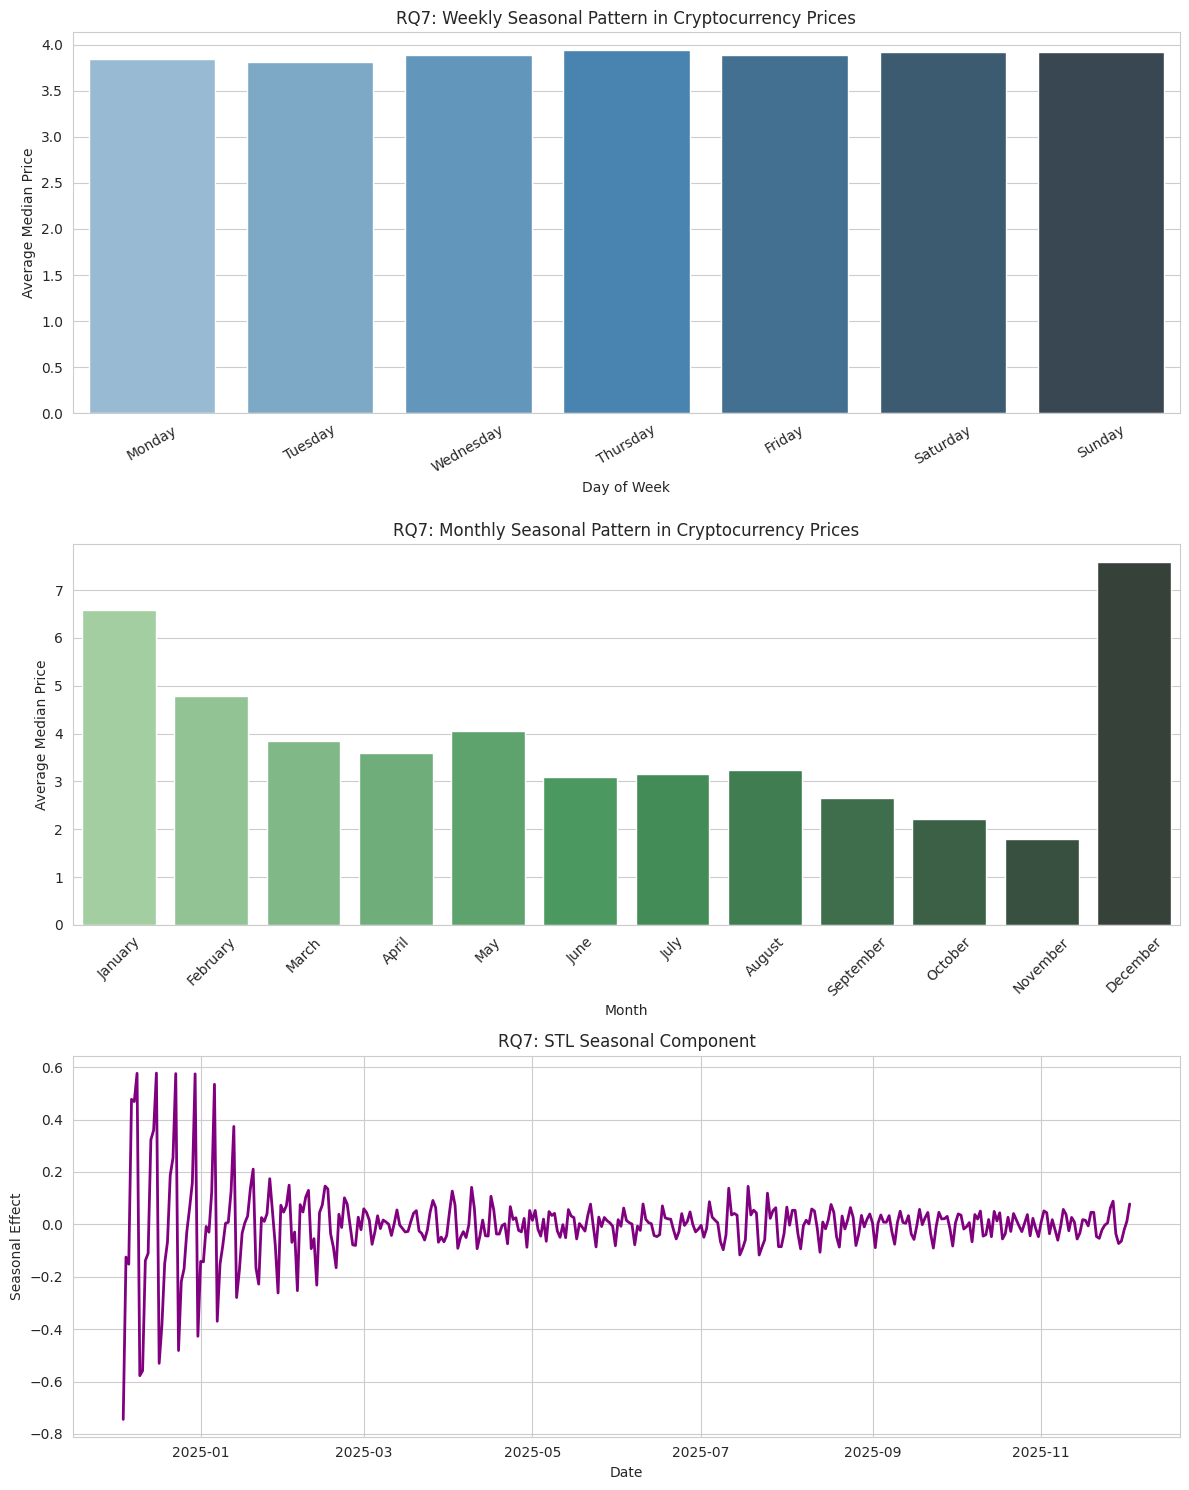

In [13]:
# RQ7: Seasonal Patterns
# Are there recurring weekly/monthly patterns in cryptocurrency prices?

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL

DATA_PATH = "/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_historical_365days.csv"

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.lower().str.strip()
df["date"] = pd.to_datetime(df["date"])

# Build one market-level daily series
daily_series = (
    df.groupby("date")
      .agg(
          median_price=("price", "median"),
          mean_price=("price", "mean")
      )
      .reset_index()
      .sort_values("date")
)

# Create time-based labels
daily_series["day_name"] = daily_series["date"].dt.day_name()
daily_series["month_name"] = daily_series["date"].dt.month_name()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

# Weekly seasonality table
weekday_table = (
    daily_series.groupby("day_name", observed=False)["median_price"]
    .mean()
    .reindex(weekday_order)
    .dropna()
    .reset_index()
)

weekday_table.columns = ["Day", "Average_Median_Price"]
weekday_table.to_csv("/kaggle/working/RQ7_weekday_seasonality.csv", index=False)

# Monthly seasonality table
month_table = (
    daily_series.groupby("month_name", observed=False)["median_price"]
    .mean()
    .reindex(month_order)
    .dropna()
    .reset_index()
)

month_table.columns = ["Month", "Average_Median_Price"]
month_table.to_csv("/kaggle/working/RQ7_monthly_seasonality.csv", index=False)

# STL decomposition for repeating seasonal pattern
stl = STL(daily_series["median_price"], period=7, robust=True)
stl_result = stl.fit()

decomp_df = daily_series[["date", "median_price"]].copy()
decomp_df["trend"] = stl_result.trend
decomp_df["seasonal"] = stl_result.seasonal
decomp_df["residual"] = stl_result.resid

decomp_df.to_csv("/kaggle/working/RQ7_stl_decomposition.csv", index=False)

print("Weekly Seasonality Table:")
display(weekday_table)

print("Monthly Seasonality Table:")
display(month_table)

# Figure
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

sns.barplot(
    data=weekday_table,
    x="Day",
    y="Average_Median_Price",
    hue="Day",
    palette="Blues_d",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("RQ7: Weekly Seasonal Pattern in Cryptocurrency Prices")
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Average Median Price")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(
    data=month_table,
    x="Month",
    y="Average_Median_Price",
    hue="Month",
    palette="Greens_d",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("RQ7: Monthly Seasonal Pattern in Cryptocurrency Prices")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Average Median Price")
axes[1].tick_params(axis="x", rotation=45)

axes[2].plot(decomp_df["date"], decomp_df["seasonal"], color="purple", linewidth=2)
axes[2].set_title("RQ7: STL Seasonal Component")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Seasonal Effect")

plt.tight_layout()
plt.savefig("/kaggle/working/RQ7_seasonality.pdf")
plt.show()
